# Full Pipeline Accuracy Review

This notebook ingests the artifacts produced by `scripts/run_full_pipeline_llama_unlearn.sh` and reports the accuracies for every LLaMA/Qwen training regime.

* **Section 1** loads every `eval_result/accuracies_ckpts*.json` blob and validates that the expected checkpoints produced metrics.
* **Section 2** renders human-readable comparison tables for each model family (global + per-client).
* **Section 3** visualizes the same comparisons, grouped by benchmark.

Run each cell from the root of the FederatedScope checkout so that relative paths resolve correctly.

## 1. Data ingestion and formatting

In [8]:
import json
import re
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.options.display.float_format = '{:,.4f}'.format

In [9]:
FS_ROOT = Path.cwd()
PIPELINE_SCRIPT = FS_ROOT / "scripts" / "run_full_pipeline_llama_unlearn.sh"
EVAL_DIR = FS_ROOT / "eval_result"
RESULTS_DIR = FS_ROOT / "results_full"
LOG_DIR = FS_ROOT / "logs"

print(f"Repo root        : {FS_ROOT}")
print(f"Pipeline script  : {PIPELINE_SCRIPT}")
print(f"Eval artifacts   : {EVAL_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Logs directory   : {LOG_DIR}")

for path, desc in [
    (PIPELINE_SCRIPT, "pipeline script"),
    (EVAL_DIR, "eval_result directory"),
    (RESULTS_DIR, "results_full directory"),
    (LOG_DIR, "logs directory"),
]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {desc}: {path}")

Repo root        : /storage/ice1/7/0/sbhansali8/FederatedScope
Pipeline script  : /storage/ice1/7/0/sbhansali8/FederatedScope/scripts/run_full_pipeline_llama_unlearn.sh
Eval artifacts   : /storage/ice1/7/0/sbhansali8/FederatedScope/eval_result
Results directory: /storage/ice1/7/0/sbhansali8/FederatedScope/results_full
Logs directory   : /storage/ice1/7/0/sbhansali8/FederatedScope/logs


In [10]:

MODEL_DIR_TO_KEY = {
    'llama2': 'llama2_composite_meta3',
    'llama2_unlearn': 'llama2_composite_meta3_unlearn',
    'llama2_unlearn_shrink05': 'llama2_composite_meta3_unlearn_shrink05',
    'llama2_unlearn_loo': 'llama2_composite_meta3_unlearn_loo',
    'llama2_unlearn_loo_shrink05': 'llama2_composite_meta3_unlearn_loo_shrink05',
    'qwen_moe': 'qwen15moe_composite_meta3',
    'qwen15moe': 'qwen15moe_composite_meta3',
    'qwen15moe_unlearn': 'qwen15moe_composite_meta3_unlearn',
    'qwen15moe_unlearn_shrink05': 'qwen15moe_composite_meta3_unlearn_shrink05'
}

BENCHMARK_NORMALIZATION = {
    'all_in_one': 'mmlu',
    'interleaved_all_in_one': 'mmlu',
    'gsm8k_local': 'gsm8k',
    'gsm8k': 'gsm8k',
    'code_local': 'code',
    'code': 'code',
    'instr_local': 'mmlu',
    'mmlu': 'mmlu',
    None: 'mmlu',
    '': 'mmlu'
}

BENCHMARK_LABELS = {
    'mmlu': 'MMLU',
    'gsm8k': 'GSM8K',
    'code': 'Code'
}

SINGLE_TASK_BASELINE_TARGETS = {
    'code_local': 'code',
    'gsm8k_local': 'gsm8k',
    'instr_local': 'mmlu'
}

BASELINE_BENCHMARK_SUFFIXES = [
    'interleaved_all_in_one',
    'all_in_one',
    'instr_local',
    'gsm8k_local',
    'code_local'
]

FAMILY_LABELS = {
    'llama2': 'LLaMA 2',
    'llama2_composite_meta3': 'LLaMA 2',
    'llama2_composite_meta3_unlearn': 'LLaMA 2',
    'llama2_composite_meta3_unlearn_shrink05': 'LLaMA 2',
    'llama2_composite_meta3_unlearn_loo': 'LLaMA 2',
    'llama2_composite_meta3_unlearn_loo_shrink05': 'LLaMA 2',
    'qwen_moe': 'Qwen 1.5 MoE',
    'qwen15moe': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3_unlearn': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3_unlearn_shrink05': 'Qwen 1.5 MoE'
}

FAMILY_BENCHMARKS = {
    'LLaMA 2': ['mmlu', 'gsm8k', 'code'],
    'Qwen 1.5 MoE': ['mmlu', 'gsm8k', 'code']
}

CLIENT_IDS = ['client_1', 'client_2', 'client_3']
CLIENT_TITLES = [f"Client {cid.split('_')[-1]}" for cid in CLIENT_IDS]

GLOBAL_COLUMN_SPECS = [
    ('Global · Baseline (Code only)', {'scope': 'baseline', 'benchmark_raw': 'code_local'}),
    ('Global · Baseline (GSM8K only)', {'scope': 'baseline', 'benchmark_raw': 'gsm8k_local'}),
    ('Global · Baseline (Instruction only)', {'scope': 'baseline', 'benchmark_raw': 'instr_local'}),
    ('Global · Baseline (All-in-one)', {'scope': 'baseline', 'benchmark_raw': 'all_in_one'}),
    ('Global · Baseline (Interleaved)', {'scope': 'baseline', 'benchmark_raw': 'interleaved_all_in_one'}),
    ('Global · Standard FL', {'scope': 'global', 'variant': 'Standard'}),
    ('Global · Unlearn', {'scope': 'global', 'variant': 'Unlearn'}),
    ('Global · Unlearn (shrink=0.5)', {'scope': 'global', 'variant': 'Unlearn (shrink=0.5)'}),
    ('Global · Unlearn (LOO)', {'scope': 'global', 'variant': 'Unlearn (LOO)'}),
    ('Global · Unlearn (LOO, shrink=0.5)', {'scope': 'global', 'variant': 'Unlearn (LOO, shrink=0.5)'})
]

CLIENT_COLUMN_SPECS = []
for cid, title in zip(CLIENT_IDS, CLIENT_TITLES):
    CLIENT_COLUMN_SPECS.extend([
        (f"{title} · Standard", {'scope': 'client', 'variant': 'Standard', 'client': cid}),
        (f"{title} · Unlearn", {'scope': 'client', 'variant': 'Unlearn', 'client': cid}),
        (f"{title} · Unlearn (shrink=0.5)", {'scope': 'client', 'variant': 'Unlearn (shrink=0.5)', 'client': cid}),
        (f"{title} · Unlearn (LOO)", {'scope': 'client', 'variant': 'Unlearn (LOO)', 'client': cid}),
        (f"{title} · Unlearn (LOO, shrink=0.5)", {'scope': 'client', 'variant': 'Unlearn (LOO, shrink=0.5)', 'client': cid}),
    ])

CATEGORY_ORDER = ['STEM', 'humanities', 'social sciences', 'other (business, health, misc.)']


In [11]:
def infer_family(model_key: str) -> str:
    for token, label in FAMILY_LABELS.items():
        if model_key.startswith(token):
            return label
    return model_key


def infer_variant(model_key: str, scope: str, benchmark: Optional[str], client: Optional[str]) -> str:
    if scope == 'baseline':
        if benchmark == 'all_in_one':
            return 'Baseline (All-in-one)'
        if benchmark == 'interleaved_all_in_one':
            return 'Baseline (Interleaved)'
        label = benchmark.replace('_', ' ').title() if benchmark else 'Baseline'
        return f'Baseline ({label})'
    if scope == 'client':
        if 'unlearn_loo_shrink05' in model_key:
            return 'Unlearn (LOO, shrink=0.5)'
        if 'unlearn_loo' in model_key:
            return 'Unlearn (LOO)'
        if 'unlearn_shrink05' in model_key:
            return 'Unlearn (shrink=0.5)'
        if 'unlearn' in model_key:
            return 'Unlearn'
        return 'Standard'
    if 'unlearn_loo_shrink05' in model_key:
        return 'Unlearn (LOO, shrink=0.5)'
    if 'unlearn_loo' in model_key:
        return 'Unlearn (LOO)'
    if 'unlearn_shrink05' in model_key:
        return 'Unlearn (shrink=0.5)'
    if 'unlearn' in model_key:
        return 'Unlearn'
    return 'Standard'


def parse_accuracy_file(path: Path) -> dict:
    filename = path.name
    if not filename.startswith('accuracies_') or not filename.endswith('.json'):
        return None
    core = filename[len('accuracies_'):-5]
    benchmark_override = None
    if '__' in core:
        core, benchmark_override = core.rsplit('__', 1)
    if core.startswith('ckpts_'):
        core = core[len('ckpts_'):]
    if core.endswith('.ckpt'):
        core = core[:-5]

    raw_name = core
    scale = 'full' if raw_name.startswith('full_') else 'default'
    descriptor = raw_name[5:] if scale == 'full' else raw_name

    scope = 'global'
    model_key = descriptor
    benchmark = benchmark_override
    eval_benchmark = benchmark_override
    client = None
    lookup_key = model_key

    if descriptor.startswith('baselines_'):
        scope = 'baseline'
        rest = descriptor[len('baselines_'):]
        matched_suffix = None
        for suffix in BASELINE_BENCHMARK_SUFFIXES:
            token = f'_{suffix}'
            if rest.endswith(token):
                matched_suffix = suffix
                model_key = rest[:-len(token)]
                break
        if matched_suffix is None:
            parts = rest.split('_', 1)
            model_key = parts[0]
            matched_suffix = parts[1] if len(parts) > 1 else benchmark_override
        benchmark = matched_suffix
        lookup_key = model_key
    elif '_clients_' in descriptor:
        scope = 'client'
        model_key, client_part = descriptor.split('_clients_', 1)
        match = re.search(r'client_(\d+)', client_part)
        client = f"client_{match.group(1)}" if match else client_part
        lookup_key = model_key

    family = infer_family(model_key)
    variant = infer_variant(model_key, scope, benchmark, client)

    eval_benchmark = eval_benchmark or benchmark

    record = {
        'file': str(path.relative_to(FS_ROOT)),
        'raw_name': raw_name,
        'scale': scale,
        'scope': scope,
        'model_key': model_key,
        'lookup_key': lookup_key,
        'model_family': family,
        'variant': variant,
        'benchmark': benchmark,
        'benchmark_eval': eval_benchmark,
        'client': client,
        'weighted_accuracy': None,
        'categories': {},
        'subcategories': {},
    }

    try:
        with path.open() as f:
            payload = json.load(f)
        record['weighted_accuracy'] = payload.get('weighted_accuracy')
        record['categories'] = payload.get('categories', {})
        record['subcategories'] = payload.get('subcategories', {})
    except json.JSONDecodeError as exc:
        print(f"Skipping {path}: {exc}")
        return None

    if record['benchmark'] is None:
        record['benchmark'] = ''
    if record['benchmark_eval'] is None:
        record['benchmark_eval'] = ''

    record['match_key'] = (
        record['scope'],
        record['scale'],
        record['lookup_key'],
        record['benchmark'],
        record['client'] or ''
    )
    return record

records = []
for accuracy_path in sorted(EVAL_DIR.glob('accuracies_ckpts*.json')):
    record = parse_accuracy_file(accuracy_path)
    if record is not None:
        records.append(record)

if not records:
    raise RuntimeError('No accuracy files were found – rerun the evaluations.')

records_df = pd.DataFrame(records)
records_df['benchmark_eval'] = records_df['benchmark_eval'].fillna('')
records_df['benchmark_norm'] = records_df['benchmark_eval'].map(
    lambda key: BENCHMARK_NORMALIZATION.get(key, 'mmlu')
)
category_columns = sorted({k for rec in records for k in rec['categories'].keys()})
for col in category_columns:
    records_df[col] = records_df['categories'].apply(lambda d: d.get(col))

records_df = records_df.sort_values(by=['scope', 'model_family', 'variant']).reset_index(drop=True)
print(f"Loaded {len(records_df)} accuracy artifacts.")
display(records_df.head())


Loaded 92 accuracy artifacts.


,file,raw_name,scale,scope,model_key,lookup_key,model_family,variant,benchmark,benchmark_eval,...,go,gsm8k,humanities,java,javascript,"other (business, health, misc.)",php,python,ruby,social sciences
0,eval_result/accuracies_ckpts_baselines_llama2_...,baselines_llama2_all_in_one,default,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,all_in_one,...,NaN,NaN,0.3535,NaN,NaN,0.4827,NaN,NaN,NaN,0.4927
1,eval_result/accuracies_ckpts_full_baselines_ll...,full_baselines_llama2_all_in_one,full,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,all_in_one,...,NaN,NaN,0.3424,NaN,NaN,0.4843,NaN,NaN,NaN,0.4842
2,eval_result/accuracies_ckpts_full_baselines_ll...,full_baselines_llama2_all_in_one,full,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,code,...,0.5114,NaN,NaN,0.5314,0.5170,NaN,0.5449,0.5419,0.5437,NaN
3,eval_result/accuracies_ckpts_full_baselines_ll...,full_baselines_llama2_all_in_one,full,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,gsm8k,...,NaN,0.0705,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,eval_result/accuracies_ckpts_baselines_llama2_...,baselines_llama2_code_local,default,baseline,llama2,llama2,LLaMA 2,Baseline (Code Local),code_local,code_local,...,NaN,NaN,0.3269,NaN,NaN,0.4056,NaN,NaN,NaN,0.4335


In [12]:
expected_entries = []

for dir_name, model_key in MODEL_DIR_TO_KEY.items():
  candidate = RESULTS_DIR / 'global' / dir_name
  if candidate.exists():
    for benchmark_dir in candidate.iterdir():
      if benchmark_dir.is_dir():
        expected_entries.append({
            'scope': 'global', 'scale': 'full', 'lookup_key': model_key,
            'benchmark': benchmark_dir.name, 'client': '', 'source_path': str(benchmark_dir)
        })

clients_root = RESULTS_DIR / 'clients'
if clients_root.exists():
  for dir_name, model_key in MODEL_DIR_TO_KEY.items():
    model_dir = clients_root / dir_name
    if not model_dir.exists():
      continue
    for client_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
      expected_entries.append({
          'scope': 'client', 'scale': 'full', 'lookup_key': model_key,
          'benchmark': client_dir.name, 'client': client_dir.name, 'source_path': str(client_dir)
      })

baselines_root = RESULTS_DIR / 'baselines'
if baselines_root.exists():
  for model_dir in sorted(p for p in baselines_root.iterdir() if p.is_dir()):
    for bench_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
      expected_entries.append({
          'scope': 'baseline', 'scale': 'full', 'lookup_key': model_dir.name,
          'benchmark': bench_dir.name, 'client': '', 'source_path': str(bench_dir)
      })

expected_df = pd.DataFrame(expected_entries)
if expected_df.empty:
  print('results_full/ is empty – no expectations could be derived.')
else:
  expected_df['match_key'] = list(zip(
      expected_df['scope'], expected_df['scale'], expected_df['lookup_key'],
      expected_df['benchmark'], expected_df['client']
  ))
  have_keys = set(records_df['match_key'])
  expected_df['present'] = expected_df['match_key'].apply(lambda key: key in have_keys)
  missing_df = expected_df[~expected_df['present']].copy()
  if missing_df.empty:
    print('All expected accuracy files are present in eval_result/.')
  else:
    print('Accuracy artifacts missing from eval_result/:')
    display(missing_df[['scope', 'lookup_key', 'benchmark', 'client', 'source_path']])

Accuracy artifacts missing from eval_result/:


,scope,lookup_key,benchmark,client,source_path
1,global,llama2_composite_meta3,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
4,global,llama2_composite_meta3_unlearn,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
7,global,llama2_composite_meta3_unlearn_shrink05,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
10,global,qwen15moe_composite_meta3,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
11,global,qwen15moe_composite_meta3,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
13,global,qwen15moe_composite_meta3_unlearn,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
15,global,qwen15moe_composite_meta3_unlearn_shrink05,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
16,client,llama2_composite_meta3,client_1,client_1,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
17,client,llama2_composite_meta3,client_2,client_2,/storage/ice1/7/0/sbhansali8/FederatedScope/re...
18,client,llama2_composite_meta3,client_3,client_3,/storage/ice1/7/0/sbhansali8/FederatedScope/re...


## 2. Human-readable tables

In [13]:
def fetch_metric(family: str, benchmark: str, spec: dict) -> float:
    subset = records_df[
        (records_df['model_family'] == family)
        & (records_df['benchmark_norm'] == benchmark)
        & (records_df['scale'] == 'full')
    ]
    subset = subset[subset['scope'] == spec.get('scope', 'global')]
    if 'variant' in spec:
        subset = subset[subset['variant'] == spec['variant']]
    if 'client' in spec:
        subset = subset[subset['client'] == spec['client']]
    if 'benchmark_raw' in spec:
        subset = subset[subset['benchmark'] == spec['benchmark_raw']]
    if subset.empty:
        return np.nan
    return subset.iloc[0]['weighted_accuracy']


def build_family_table(family: str) -> pd.DataFrame:
    benchmarks = FAMILY_BENCHMARKS.get(family, [])
    rows = []
    missing_cells = []
    for bench in benchmarks:
        row = {'Benchmark': BENCHMARK_LABELS.get(bench, bench)}
        for label, spec in GLOBAL_COLUMN_SPECS + CLIENT_COLUMN_SPECS:
            value = fetch_metric(family, bench, spec)
            if np.isnan(value):
                missing_cells.append({'Benchmark': row['Benchmark'], 'Column': label})
            row[label] = value
        rows.append(row)
    return pd.DataFrame(rows), pd.DataFrame(missing_cells)

llama_table, llama_missing = build_family_table('LLaMA 2')
print('LLaMA 2 accuracies (global + clients):')
display(llama_table)
if not llama_missing.empty:
    print('Missing LLaMA 2 entries (these still need evaluation artifacts):')
    display(llama_missing.drop_duplicates())

qwen_table, qwen_missing = build_family_table('Qwen 1.5 MoE')
print('Qwen 1.5 MoE accuracies (global + clients):')
display(qwen_table)
if not qwen_missing.empty:
    print('Missing Qwen entries:')
    display(qwen_missing.drop_duplicates())

LLaMA 2 accuracies (global + clients):


,Benchmark,Global · Baseline (Code only),Global · Baseline (GSM8K only),Global · Baseline (Instruction only),Global · Baseline (All-in-one),Global · Baseline (Interleaved),Global · Standard FL,Global · Unlearn,Global · Unlearn (shrink=0.5),Client 1 · Standard,Client 1 · Unlearn,Client 1 · Unlearn (shrink=0.5),Client 2 · Standard,Client 2 · Unlearn,Client 2 · Unlearn (shrink=0.5),Client 3 · Standard,Client 3 · Unlearn,Client 3 · Unlearn (shrink=0.5)
0,MMLU,NaN,NaN,0.3875,0.4116,0.3628,0.2751,0.4174,0.4173,0.2294,0.3541,0.3608,0.2331,0.3424,0.3478,0.2396,0.3888,0.3837
1,GSM8K,0.0538,0.3887,0.0819,0.0705,0.0743,0.0273,0.0834,0.0970,0.0099,0.1190,0.0970,0.0136,0.1077,0.1418,0.0114,0.0879,0.1016
2,Code,0.3378,0.4959,0.5104,0.5340,0.5142,0.4889,0.5122,0.5087,0.5040,0.4998,0.4997,0.5088,0.4994,0.4996,0.5010,0.5000,0.4998


Missing LLaMA 2 entries (these still need evaluation artifacts):


,Benchmark,Column
0,MMLU,Global · Baseline (Code only)
1,MMLU,Global · Baseline (GSM8K only)


Qwen 1.5 MoE accuracies (global + clients):


,Benchmark,Global · Baseline (Code only),Global · Baseline (GSM8K only),Global · Baseline (Instruction only),Global · Baseline (All-in-one),Global · Baseline (Interleaved),Global · Standard FL,Global · Unlearn,Global · Unlearn (shrink=0.5),Client 1 · Standard,Client 1 · Unlearn,Client 1 · Unlearn (shrink=0.5),Client 2 · Standard,Client 2 · Unlearn,Client 2 · Unlearn (shrink=0.5),Client 3 · Standard,Client 3 · Unlearn,Client 3 · Unlearn (shrink=0.5)
0,MMLU,NaN,NaN,0.5333,0.5327,NaN,0.5254,NaN,NaN,0.5207,NaN,NaN,0.5169,NaN,NaN,0.5207,NaN,NaN
1,GSM8K,0.5792,0.5340,0.5868,0.6005,0.4845,0.5269,0.6346,0.6346,0.5042,0.6346,0.6346,0.4905,0.6346,0.6346,0.4731,0.6346,0.6346
2,Code,0.5305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing Qwen entries:


,Benchmark,Column
0,MMLU,Global · Baseline (Code only)
1,MMLU,Global · Baseline (GSM8K only)
2,MMLU,Global · Baseline (Interleaved)
3,MMLU,Global · Unlearn
4,MMLU,Global · Unlearn (shrink=0.5)
5,MMLU,Client 1 · Unlearn
6,MMLU,Client 1 · Unlearn (shrink=0.5)
7,MMLU,Client 2 · Unlearn
8,MMLU,Client 2 · Unlearn (shrink=0.5)
9,MMLU,Client 3 · Unlearn


## 3. Graphs

/tmp/ipykernel_1197160/3799906916.py:92: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', n_series)


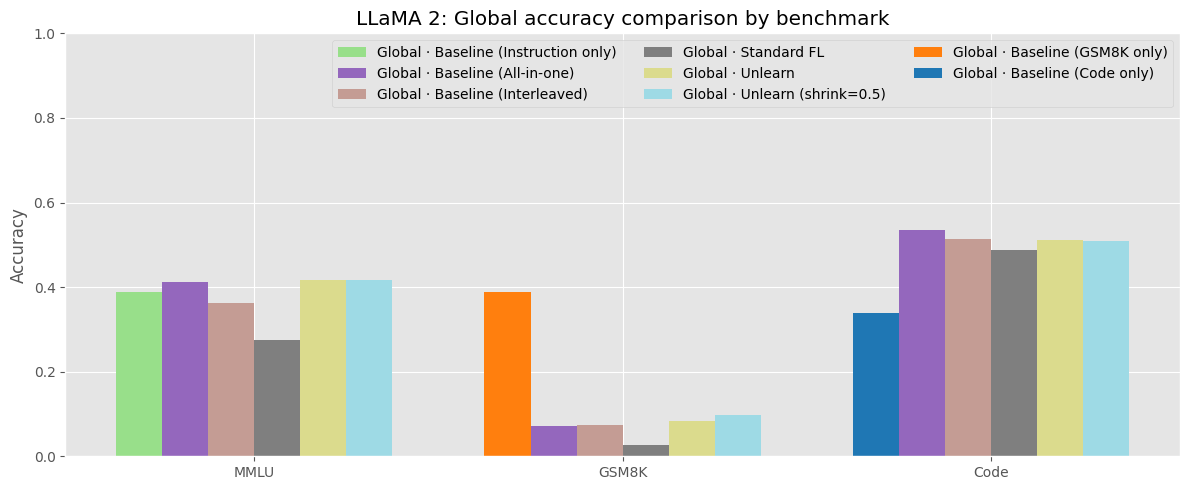

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


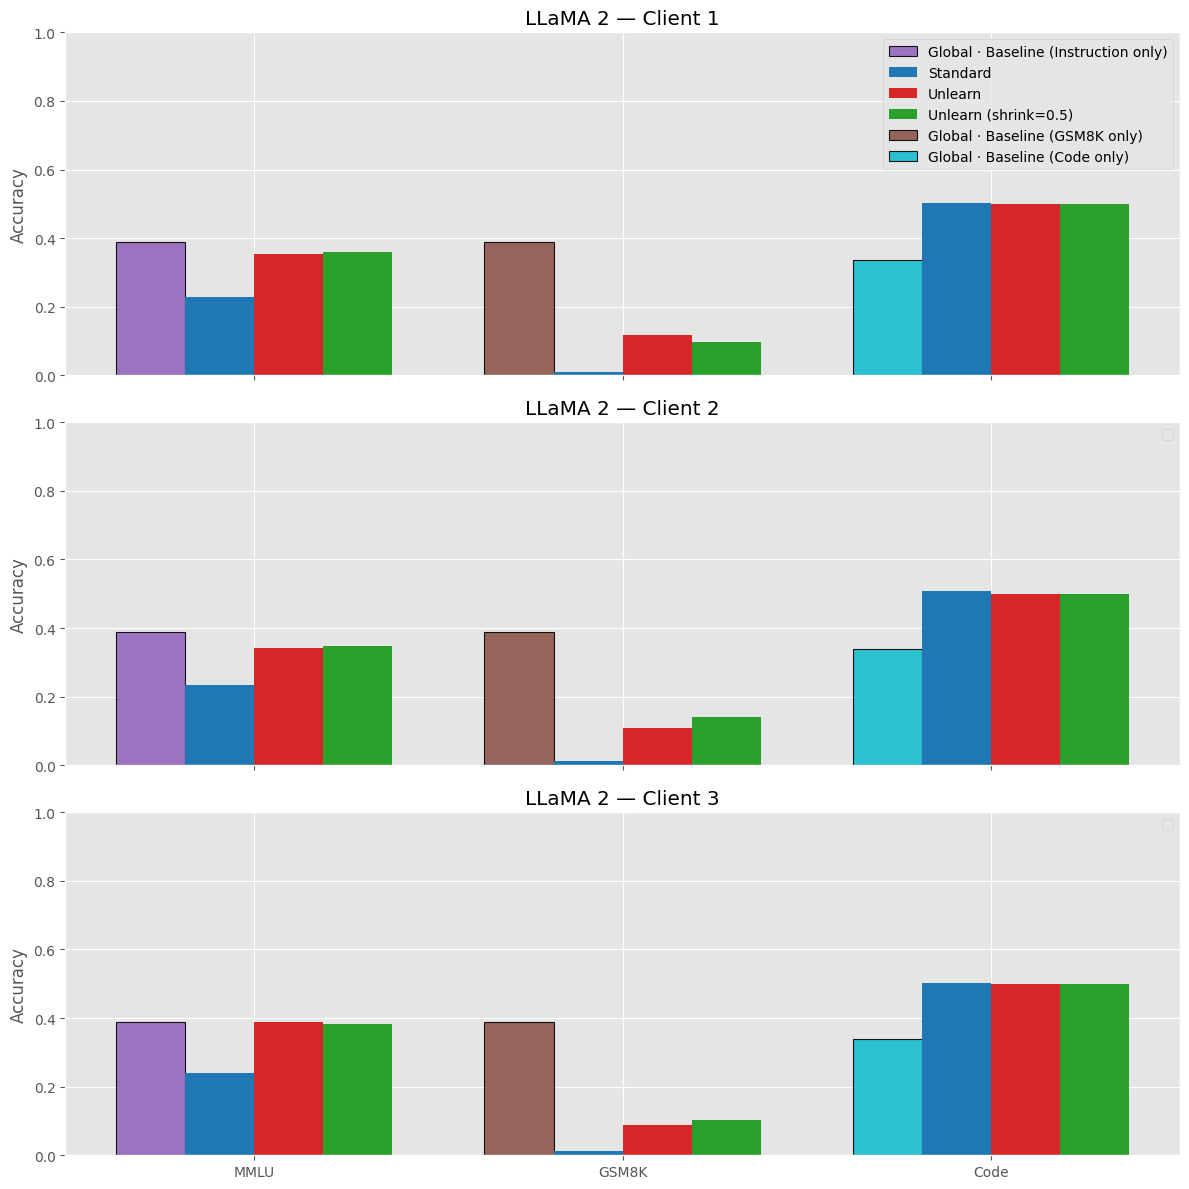

In [14]:
# === Updated plotting cell ===

GLOBAL_VARIANT_ORDER = [label for label, _ in GLOBAL_COLUMN_SPECS]
CLIENT_VARIANT_GROUPS = [
    ('Standard', {'variant': 'Standard'}),
    ('Unlearn', {'variant': 'Unlearn'}),
    ('Unlearn (shrink=0.5)', {'variant': 'Unlearn (shrink=0.5)'}),
    ('Unlearn (LOO)', {'variant': 'Unlearn (LOO)'}),
    ('Unlearn (LOO, shrink=0.5)', {'variant': 'Unlearn (LOO, shrink=0.5)'})
]
CLIENT_VARIANT_COLORS = {
    'Standard': '#1f77b4',
    'Unlearn': '#d62728',
    'Unlearn (shrink=0.5)': '#2ca02c',
    'Unlearn (LOO)': '#ff9896',
    'Unlearn (LOO, shrink=0.5)': '#98df8a'
}
BASELINE_COLOR_BY_BENCH = {
    'mmlu': '#9467bd',
    'gsm8k': '#8c564b',
    'code': '#17becf'
}

# --- Helpers for baselines ---


def _spec_applicable_to_benchmark(bench_key: str, spec: dict) -> bool:
    raw = spec.get('benchmark_raw')
    if raw in SINGLE_TASK_BASELINE_TARGETS:
        return SINGLE_TASK_BASELINE_TARGETS[raw] == bench_key
    return True

def _find_global_spec_for_label(label: str):
    for lab, spec in GLOBAL_COLUMN_SPECS:
        if lab.strip().lower() == label.strip().lower():
            return spec
    return None


def _guess_baseline_label_for_bench(bench_key: str):
    """
    Map a benchmark key to the corresponding *global* single-task baseline label.
    Tries to find a label in GLOBAL_VARIANT_ORDER that contains the right keyword.
    """
    b = (bench_key or "").lower()

    # Heuristics for common single-task baselines
    if 'mmlu' in b or 'instr' in b or 'instruction' in b:
        keyword = 'instruction'
    elif 'gsm' in b:
        keyword = 'gsm'
    elif any(k in b for k in ['code', 'humaneval', 'mbpp', 'leetcode']):
        keyword = 'code'
    else:
        # Fallback: no clear mapping
        return None

    # Prefer labels that also contain 'only' or 'baseline'
    candidates = [lab for lab in GLOBAL_VARIANT_ORDER if keyword in lab.lower()]
    if not candidates:
        return None
    preferred = [lab for lab in candidates if ('only' in lab.lower() or 'baseline' in lab.lower())]
    return preferred[0] if preferred else candidates[0]


def plot_global_benchmarks(family: str):
    benches = FAMILY_BENCHMARKS.get(family, [])
    if not benches:
        print(f'No benchmarks configured for {family}.')
        return

    data = []
    for bench in benches:
        for label, spec in GLOBAL_COLUMN_SPECS:
            if not _spec_applicable_to_benchmark(bench, spec):
                continue
            value = fetch_metric(family, bench, spec)
            data.append({
                'Benchmark': BENCHMARK_LABELS.get(bench, bench),
                'Variant': label,
                'Accuracy': value
            })

    plot_df = pd.DataFrame(data)
    if plot_df['Accuracy'].notna().sum() == 0:
        print(f'No global accuracies available for {family}.')
        return

    benches_labels = [BENCHMARK_LABELS.get(b, b) for b in benches]
    x = np.arange(len(benches_labels))

    # Make every bar column (per-variant series) a distinct, explicit color
    # (ensures uniqueness even with many variants)
    n_series = len(GLOBAL_VARIANT_ORDER)
    if n_series <= 20:
        cmap = plt.cm.get_cmap('tab20', n_series)
        variant_colors = [cmap(i) for i in range(n_series)]
    else:
        # Generate N distinct hues
        variant_colors = [plt.cm.hsv(i / n_series) for i in range(n_series)]
    variant_color_map = {variant: variant_colors[idx] for idx, variant in enumerate(GLOBAL_VARIANT_ORDER)}

    fig, ax = plt.subplots(figsize=(12, 5))
    legend_shown = set()

    for bench_idx, bench_key in enumerate(benches):
        bench_label = benches_labels[bench_idx]
        bench_variants = [
            (label, spec)
            for label, spec in GLOBAL_COLUMN_SPECS
            if _spec_applicable_to_benchmark(bench_key, spec)
        ]
        if not bench_variants:
            continue
        width = 0.75 / len(bench_variants)
        for pos, (variant, _) in enumerate(bench_variants):
            subset = plot_df[(plot_df['Benchmark'] == bench_label) & (plot_df['Variant'] == variant)]
            value = subset['Accuracy'].iloc[0] if not subset.empty else np.nan
            offset = x[bench_idx] + (pos - (len(bench_variants) - 1) / 2) * width
            color = variant_color_map.get(variant, '#7f7f7f')
            leg_label = variant if variant not in legend_shown else '_nolegend_'
            ax.bar([offset], [value], width=width, label=leg_label, color=color)
            legend_shown.add(variant)

    ax.set_xticks(x)
    ax.set_xticklabels(benches_labels)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{family}: Global accuracy comparison by benchmark')
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()


def plot_client_benchmarks(family: str):
    benches = FAMILY_BENCHMARKS.get(family, [])
    if not benches:
        print(f'No benchmarks configured for {family}.')
        return

    benches_labels = [BENCHMARK_LABELS.get(b, b) for b in benches]
    has_data = False
    fig, axes = plt.subplots(len(CLIENT_IDS), 1, figsize=(12, 4 * len(CLIENT_IDS)), sharex=True)
    if len(CLIENT_IDS) == 1:
        axes = [axes]

    x = np.arange(len(benches_labels))
    shown_labels = set()

    for ax, cid, title in zip(axes, CLIENT_IDS, CLIENT_TITLES):
        for i, (bench_key, bench_label) in enumerate(zip(benches, benches_labels)):
            num_groups = len(CLIENT_VARIANT_GROUPS) + 1  # include matching global baseline
            width = 0.75 / num_groups

            # --- Matching global baseline first ---
            base_label = _guess_baseline_label_for_bench(bench_key)
            if base_label:
                base_spec = _find_global_spec_for_label(base_label)
                if base_spec is not None:
                    base_val = fetch_metric(family, bench_key, base_spec)
                    baseline_offset = x[i] + (0 - (num_groups - 1) / 2) * width
                    baseline_color = BASELINE_COLOR_BY_BENCH.get(bench_key, '#7f7f7f')
                    leg_lab = base_label if base_label not in shown_labels else '_nolegend_'
                    ax.bar(
                        [baseline_offset],
                        [base_val],
                        width=width,
                        label=leg_lab,
                        color=baseline_color,
                        alpha=0.9,
                        edgecolor='black',
                        linewidth=0.8
                    )
                    if np.isfinite(base_val):
                        has_data = True
                        shown_labels.add(base_label)

            # --- Client variants (consistent order/colors) ---
            for pos, (lab, spec) in enumerate(CLIENT_VARIANT_GROUPS, start=1):
                filters = spec | {'scope': 'client', 'client': cid}
                val = fetch_metric(family, bench_key, filters)
                offset = x[i] + (pos - (num_groups - 1) / 2) * width
                leg_lab = lab if lab not in shown_labels else '_nolegend_'
                ax.bar(
                    [offset],
                    [val],
                    width=width,
                    label=leg_lab,
                    color=CLIENT_VARIANT_COLORS.get(lab)
                )
                if np.isfinite(val):
                    has_data = True
                    shown_labels.add(lab)

        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1.0)
        ax.set_title(f'{family} — {title}')
        ax.legend()

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(benches_labels)
    plt.tight_layout()
    if has_data:
        plt.show()
    else:
        plt.close(fig)
        print(f'Client accuracies unavailable for {family}.')

# Example calls:
plot_global_benchmarks('LLaMA 2')
plot_client_benchmarks('LLaMA 2')
# plot_global_benchmarks('Qwen 1.5 MoE')
# plot_client_benchmarks('Qwen 1.5 MoE')


## 4. LOO vs. standard UNLEARN (LLaMA 2)


In [ ]:
# === LOO vs. standard UNLEARN comparison (global + averaged clients) ===
loo_variants = [
    ('Unlearn', 'Unlearn'),
    ('Unlearn (LOO)', 'Unlearn (LOO)'),
    ('Unlearn (shrink=0.5)', 'Unlearn (shrink=0.5)'),
    ('Unlearn (LOO, shrink=0.5)', 'Unlearn (LOO, shrink=0.5)')
]
benchmarks = FAMILY_BENCHMARKS['LLaMA 2']
variant_colors = {
    'Unlearn': '#d62728',
    'Unlearn (LOO)': '#ff9896',
    'Unlearn (shrink=0.5)': '#2ca02c',
    'Unlearn (LOO, shrink=0.5)': '#98df8a'
}
fig, axes = plt.subplots(2, len(benchmarks), figsize=(5 * len(benchmarks), 8), sharey='row')
fig.suptitle('Impact of LOO aggregation on LLaMA-2 accuracies', fontsize=16)
for b_idx, benchmark in enumerate(benchmarks):
    ax_global = axes[0][b_idx]
    ax_clients = axes[1][b_idx]
    global_vals = []
    global_labels = []
    for label, variant_name in loo_variants:
        score = fetch_metric('LLaMA 2', benchmark, {'scope': 'global', 'variant': variant_name})
        global_vals.append(score)
        global_labels.append(label)
    ax_global.bar(global_labels, global_vals, color=[variant_colors[lbl] for lbl in global_labels])
    ax_global.set_title(f"Global · {BENCHMARK_LABELS[benchmark]}")
    ax_global.set_ylim(0, 1)
    ax_global.set_ylabel('Accuracy' if b_idx == 0 else '')
    ax_global.set_xticklabels(global_labels, rotation=25, ha='right')
    client_vals = []
    client_labels = []
    for label, variant_name in loo_variants:
        per_client = []
        for cid in CLIENT_IDS:
            score = fetch_metric('LLaMA 2', benchmark, {
                'scope': 'client',
                'variant': variant_name,
                'client': cid,
            })
            if not np.isnan(score):
                per_client.append(score)
        client_vals.append(np.mean(per_client) if per_client else np.nan)
        client_labels.append(label)
    ax_clients.bar(client_labels, client_vals, color=[variant_colors[lbl] for lbl in client_labels])
    ax_clients.set_title(f"Clients (avg) · {BENCHMARK_LABELS[benchmark]}")
    ax_clients.set_ylim(0, 1)
    ax_clients.set_ylabel('Accuracy' if b_idx == 0 else '')
    ax_clients.set_xticklabels(client_labels, rotation=25, ha='right')
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()
